In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')
from google.colab import files
uploaded = files.upload()
#

Saving online+retail.zip to online+retail.zip


In [ ]:
import zipfile
import io

# Assuming 'online+retail.zip' is the key in the 'uploaded' dictionary
zip_file_bytes = uploaded['online+retail.zip']

# Create a BytesIO object to treat the bytes as a file
zip_buffer = io.BytesIO(zip_file_bytes)

# Open the zip file
with zipfile.ZipFile(zip_buffer, 'r') as z:

    # Get the name of the Excel file (assuming there's only one .xlsx or .xls file)
    excel_filename_in_zip = [name for name in z.namelist() if name.endswith(('.xlsx', '.xls'))][0]

    # Read the Excel file directly from the zip's internal stream
    dataset = pd.read_excel(z.open(excel_filename_in_zip))

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
dataset.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [ ]:
dataset.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


**Handling Missing `Description` Values**

In [ ]:
# missing value description
print(f"Missing 'Description' values before: {dataset['Description'].isnull().sum()}")


dataset['Description'].fillna('Unknown', inplace=True)

# verify there is no missing value ???
print(f"Missing 'Description' values after: {dataset['Description'].isnull().sum()}")

Missing 'Description' values before: 1454
Missing 'Description' values after: 0


**Handling Missing `CustomerID` Values**

In [ ]:

print(f"Missing 'CustomerID' values before: {dataset['CustomerID'].isnull().sum()}")


dataset['CustomerID'].fillna(0, inplace=True)


dataset['CustomerID'] = dataset['CustomerID'].astype(int)


print(f"Missing 'CustomerID' values after: {dataset['CustomerID'].isnull().sum()}")
print(f"'CustomerID' Dtype after conversion: {dataset['CustomerID'].dtype}")

Missing 'CustomerID' values before: 135080
Missing 'CustomerID' values after: 0
'CustomerID' Dtype after conversion: int64


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  541909 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   541909 non-null  int64         
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 33.1+ MB


In [ ]:
dataset.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,11476.974671
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,0.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,12352.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,14382.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16255.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,6777.908326


**NEGATIVE QUANTITY**

In [ ]:
# handling negative quantity  caused by returns
returns = dataset[dataset['Quantity'] < 0]
print("--- Returns Data (Negative Quantity) ---")
display(returns.head())

dataset = dataset[dataset['Quantity'] >= 0]

print(f"\nMinimum Quantity after filtering returns: {dataset['Quantity'].min()}")
print(f"Number of rows after removing returns: {len(dataset)}")

--- Returns Data (Negative Quantity) ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548,United Kingdom



Minimum Quantity after filtering returns: 1
Number of rows after removing returns: 531285


**Understanding and Handling Negative `UnitPrice`**

In [ ]:
negative_price_entries = dataset[dataset['UnitPrice'] < 0]

print("--- Entries with Negative UnitPrice ---")
display(negative_price_entries.head())

dataset = dataset[dataset['UnitPrice'] >= 0]


print(f"Number of rows after removing negative prices: {len(dataset)}")

--- Entries with Negative UnitPrice ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,0,United Kingdom
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,0,United Kingdom


Number of rows after removing negative prices: 531283


**FINAL VERIFICATION**

In [ ]:
dataset.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,531283.000000,531283,531283.000000,531283.000000
mean,10.655299,2011-07-04 18:15:33.177910016,3.898954,11455.241500
min,1.000000,2010-12-01 08:26:00,0.000000,0.000000
25%,1.000000,2011-03-28 11:59:00,1.250000,0.000000
50%,3.000000,2011-07-20 12:01:00,2.080000,14375.000000
75%,10.000000,2011-10-19 12:35:00,4.130000,16261.000000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000
std,156.830617,NaN,35.876279,6795.280513


**Handling Cancellations based on `InvoiceNo`**

In [ ]:
#handling cancellation based on invoice
cancellations = dataset[dataset['InvoiceNo'].astype(str).str.startswith('C')]

print(f"Number of cancelled orders: {len(cancellations)}")
print("--- Sample of Cancelled Orders ---")
display(cancellations.head())

Number of cancelled orders: 0
--- Sample of Cancelled Orders ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


**CREATING TOTAL PRICE COLUMN**

In [ ]:
# Create a TotalPrice column by multiplying Quantity and UnitPrice
dataset['TotalPrice'] = dataset['Quantity'] * dataset['UnitPrice']

print("--- Dataset with new 'TotalPrice' column ---")
display(dataset.head())
# dataset.TotalPrice() # This line caused the error, it's a Series, not a callable function

--- Dataset with new 'TotalPrice' column ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


**TOTAL PRICE**

In [ ]:
print("--- Dataset Info with TotalPrice column ---")
dataset.info()

--- Dataset Info with TotalPrice column ---
<class 'pandas.core.frame.DataFrame'>
Index: 531283 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    531283 non-null  object        
 1   StockCode    531283 non-null  object        
 2   Description  531283 non-null  object        
 3   Quantity     531283 non-null  int64         
 4   InvoiceDate  531283 non-null  datetime64[ns]
 5   UnitPrice    531283 non-null  float64       
 6   CustomerID   531283 non-null  int64         
 7   Country      531283 non-null  object        
 8   TotalPrice   531283 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 40.5+ MB


In [ ]:
print("\n--- Descriptive Statistics for TotalPrice ---")
display(dataset['TotalPrice'].describe())


--- Descriptive Statistics for TotalPrice ---


,TotalPrice
count,531283.000000
mean,20.077218
std,270.058254
min,0.000000
25%,3.750000
50%,9.900000
75%,17.700000
max,168469.600000


**DUPLICATE ENTRIES**

In [ ]:
# Check for duplicate rows
duplicate_rows = dataset[dataset.duplicated()]

print(f"Number of duplicate rows found: {len(duplicate_rows)}")

if len(duplicate_rows) > 0:
    print("--- Sample of Duplicate Rows ---")
    display(duplicate_rows.head())

    # Remove duplicate rows
    dataset.drop_duplicates(inplace=True)
    print(f"\nNumber of rows after removing duplicates: {len(dataset)}")
else:
    print("No duplicate rows found.")

Number of duplicate rows found: 5231
--- Sample of Duplicate Rows ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908,United Kingdom,1.25
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908,United Kingdom,2.10
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908,United Kingdom,2.95
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908,United Kingdom,4.95
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920,United Kingdom,2.95



Number of rows after removing duplicates: 526052


**EDA**

In [ ]:
print("--- Final Descriptive Statistics of Cleaned Dataset ---")
display(dataset.describe())

--- Final Descriptive Statistics of Cleaned Dataset ---


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,526052.000000,526052,526052.000000,526052.000000,526052.000000
mean,10.730911,2011-07-04 13:30:26.891600384,3.913818,11413.287416,20.230150
min,1.000000,2010-12-01 08:26:00,0.000000,0.000000,0.000000
25%,1.000000,2011-03-28 11:36:00,1.250000,0.000000,3.900000
50%,4.000000,2011-07-19 17:17:00,2.080000,14334.000000,9.920000
75%,11.000000,2011-10-19 11:13:00,4.130000,16242.000000,17.700000
max,80995.000000,2011-12-09 12:50:00,13541.330000,18287.000000,168469.600000
std,157.592136,NaN,36.053205,6812.665708,271.391911


**Extract date from invoice for daily sales**

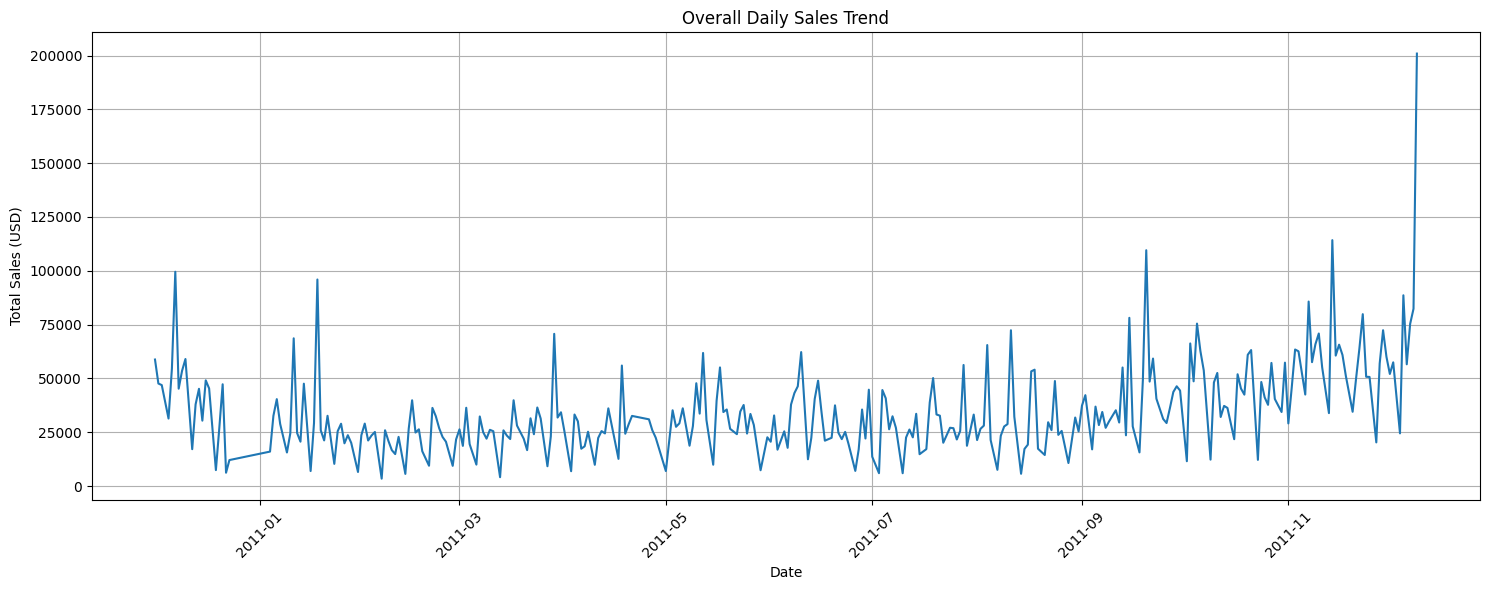

In [ ]:
import seaborn as sns
# Extract date from InvoiceDate for daily aggregation
dataset['InvoiceDay'] = dataset['InvoiceDate'].dt.date

# Group by InvoiceDay and sum TotalPrice to get daily sales
daily_sales = dataset.groupby('InvoiceDay')['TotalPrice'].sum().reset_index()

# Convert InvoiceDay back to datetime for plotting
daily_sales['InvoiceDay'] = pd.to_datetime(daily_sales['InvoiceDay'])

plt.figure(figsize=(15, 6))
sns.lineplot(x='InvoiceDay', y='TotalPrice', data=daily_sales)
plt.title('Overall Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Top 10 product and  product revenue**

--- Top 10 Products by Revenue ---


,Description,StockCode,TotalPrice
1122,DOTCOM POSTAGE,DOT,206248.77
2967,REGENCY CAKESTAND 3 TIER,22423,174156.54
2488,"PAPER CRAFT , LITTLE BIRDIE",23843,168469.60
4434,WHITE HANGING HEART T-LIGHT HOLDER,85123A,104284.24
2515,PARTY BUNTING,47566,99445.23
1905,JUMBO BAG RED RETROSPOT,85099B,94159.81
2145,MEDIUM CERAMIC TOP STORAGE JAR,23166,81700.92
2803,POSTAGE,POST,78101.88
2290,Manual,M,77750.27
2852,RABBIT NIGHT LIGHT,23084,66870.03


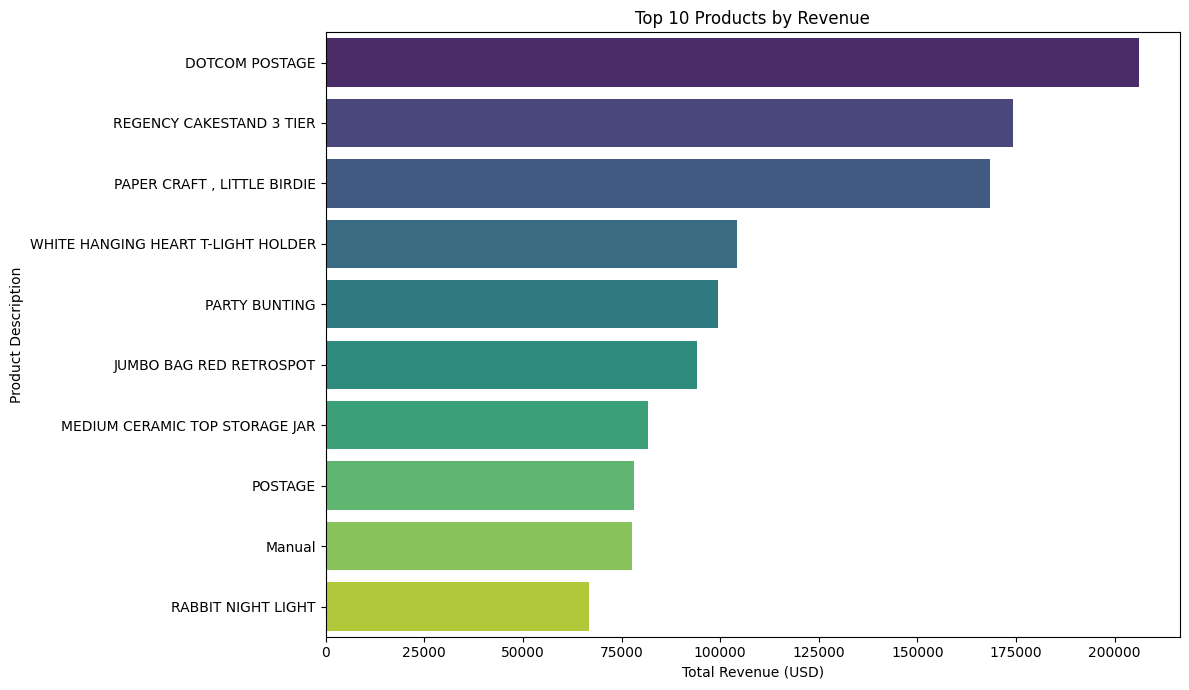

In [ ]:
# Group by product (Description and StockCode) and sum TotalPrice
product_revenue = dataset.groupby(['Description', 'StockCode'])['TotalPrice'].sum().reset_index()

# Sort in descending order to get the top products
top_10_products = product_revenue.sort_values(by='TotalPrice', ascending=False).head(10)

print("--- Top 10 Products by Revenue ---")
display(top_10_products)

# Visualize the top 10 products
plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='Description', data=top_10_products, palette='viridis')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Total Revenue (USD)')
plt.ylabel('Product Description')
plt.tight_layout()
plt.show()

--- Top 10 Customers by Spending ---


,CustomerID,TotalPrice
1690,14646,280206.02
4202,18102,259657.30
3729,17450,194390.79
3009,16446,168472.50
1880,14911,143711.17
55,12415,124914.53
1334,14156,117210.08
3772,17511,91062.38
2703,16029,80850.84
0,12346,77183.60


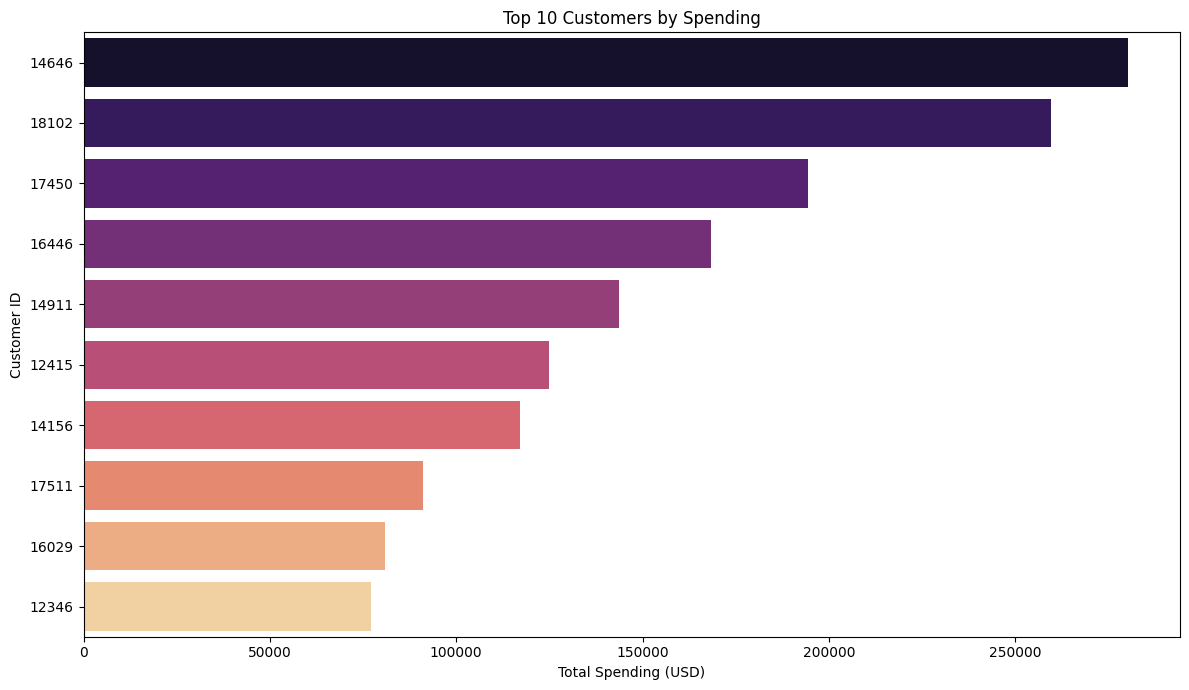

In [ ]:
# Group by CustomerID and sum TotalPrice, excluding CustomerID 0 (unknown)
customer_revenue = dataset[dataset['CustomerID'] != 0].groupby('CustomerID')['TotalPrice'].sum().reset_index()

# Sort in descending order to get the top customers
top_10_customers = customer_revenue.sort_values(by='TotalPrice', ascending=False).head(10)

print("--- Top 10 Customers by Spending ---")
display(top_10_customers)

# Visualize the top 10 customers
plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='CustomerID', data=top_10_customers.astype({'CustomerID': str}), palette='magma') # Convert CustomerID to string for better plotting
plt.title('Top 10 Customers by Spending')
plt.xlabel('Total Spending (USD)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.show()

**TOP 10 COUNTRIES**

--- Top Countries by Total Sales ---


,Country,TotalPrice
36,United Kingdom,9001744.094
24,Netherlands,285446.340
10,EIRE,283140.520
14,Germany,228678.400
13,France,209625.370
0,Australia,138453.810
31,Spain,61558.560
33,Switzerland,57067.600
3,Belgium,41196.340
32,Sweden,38367.830


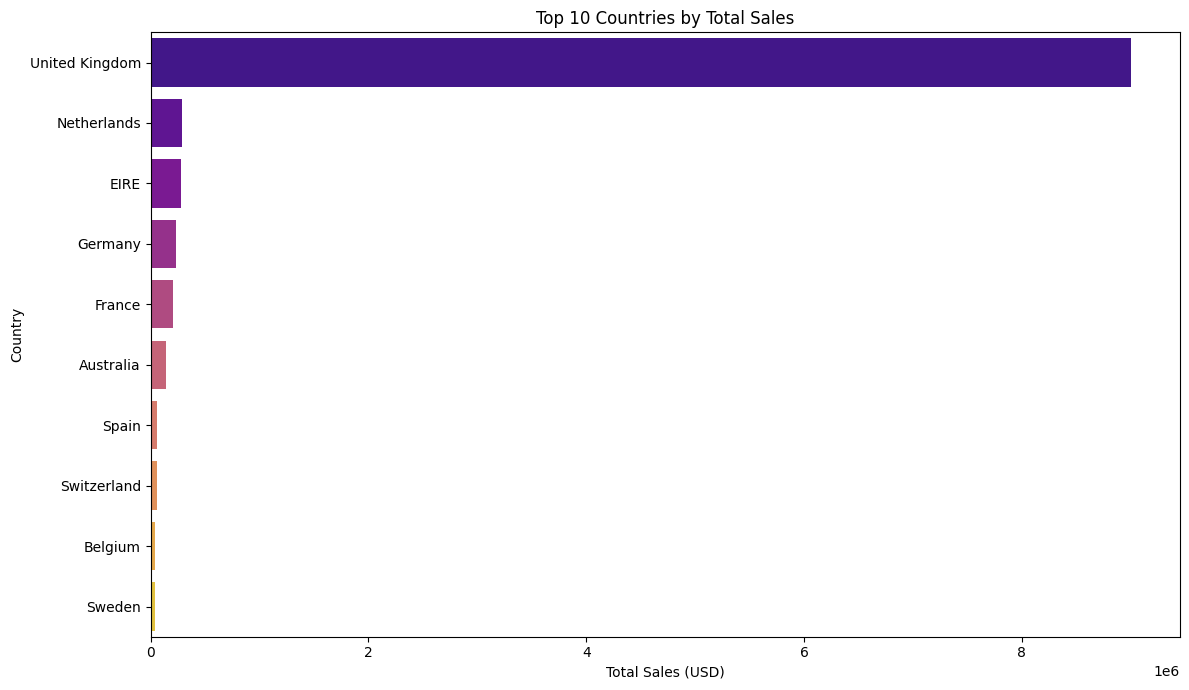

In [ ]:
top_countries = dataset.groupby('Country')['TotalPrice'].sum().reset_index()

# SortIN DESCENDING ORDER
top_countries = top_countries.sort_values(by='TotalPrice', ascending=False)

print("--- Top Countries by Total Sales ---")
display(top_countries.head(10))

plt.figure(figsize=(12, 7))
sns.barplot(x='TotalPrice', y='Country', data=top_countries.head(10), palette='plasma')
plt.title('Top 10 Countries by Total Sales')
plt.xlabel('Total Sales (USD)')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

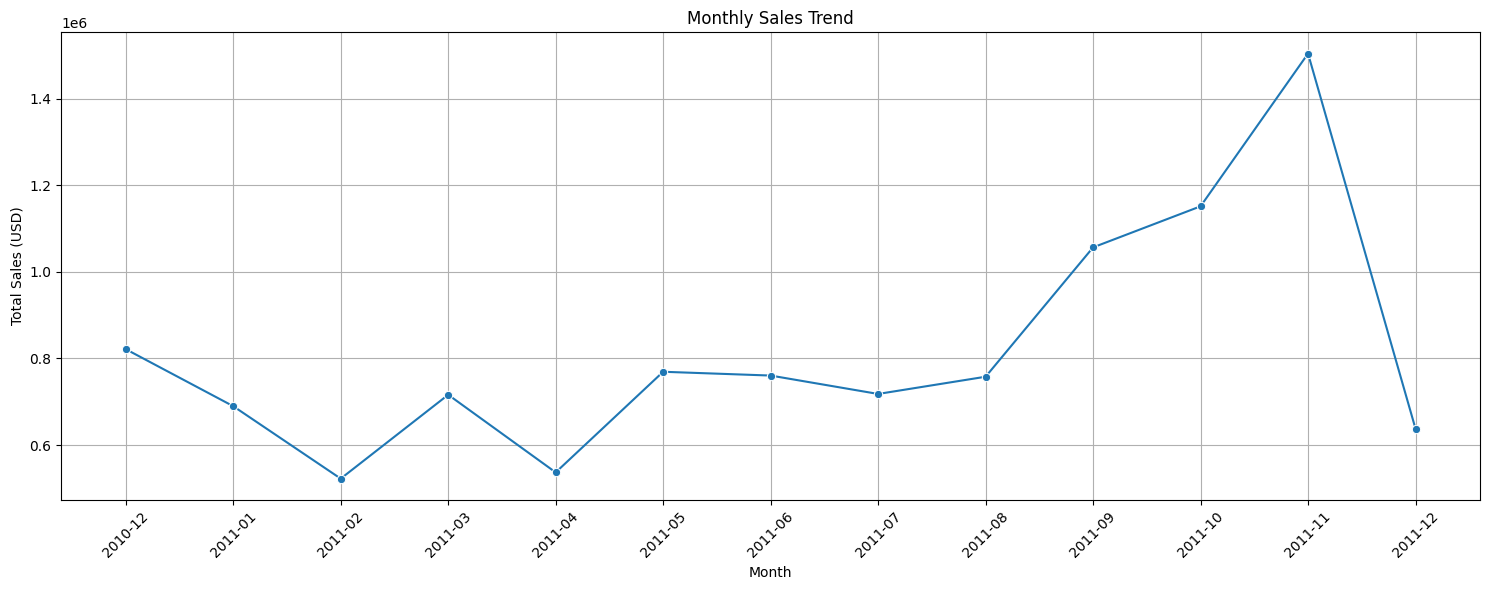

In [ ]:
# Extract year and month for monthly aggregation
dataset['InvoiceMonth'] = dataset['InvoiceDate'].dt.to_period('M')

# Group by InvoiceMonth and sum TotalPrice to get monthly sales
monthly_sales = dataset.groupby('InvoiceMonth')['TotalPrice'].sum().reset_index()

# Convert InvoiceMonth back to datetime for plotting
monthly_sales['InvoiceMonth'] = monthly_sales['InvoiceMonth'].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(x='InvoiceMonth', y='TotalPrice', data=monthly_sales, marker='o')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales (USD)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**RFM ANALYSIS**

In [ ]:
snapshot_date = dataset['InvoiceDate'].max() + pd.Timedelta(days=1)

print("Snapshot Date:", snapshot_date)

Snapshot Date: 2011-12-10 12:50:00


**RFM TABLE**

In [ ]:
rfm = dataset.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
}).reset_index()

In [ ]:
rfm.columns = [
    'CustomerID',
    'Recency',
    'Frequency',
    'Monetary'
]

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,0,1,2190,1754901.91
1,12346,326,1,77183.60
2,12347,2,7,4310.00
3,12348,75,4,1797.24
4,12349,19,1,1757.55


In [ ]:
rfm = rfm[rfm['CustomerID'] != 0]

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
1,12346,326,1,77183.60
2,12347,2,7,4310.00
3,12348,75,4,1797.24
4,12349,19,1,1757.55
5,12350,310,1,334.40


In [ ]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,2048.215924
std,1721.889758,100.009747,7.705493,8984.248352
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,306.455000
50%,15299.000000,51.000000,2.000000,668.560000
75%,16778.500000,142.000000,5.000000,1660.315000
max,18287.000000,374.000000,210.000000,280206.020000


In [ ]:
dataset[dataset['CustomerID'] == 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,InvoiceDay,InvoiceMonth
622,536414,22139,Unknown,56,2010-12-01 11:52:00,0.00,0,United Kingdom,0.00,2010-12-01,2010-12
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,0,United Kingdom,2.51,2010-12-01,2010-12
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,0,United Kingdom,5.02,2010-12-01,2010-12
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,0,United Kingdom,3.40,2010-12-01,2010-12
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,0,United Kingdom,3.32,2010-12-01,2010-12


In [ ]:
dataset[dataset['CustomerID'] == 0].shape

(133320, 11)

In [ ]:
rfm.describe()

,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,2048.215924
std,1721.889758,100.009747,7.705493,8984.248352
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,306.455000
50%,15299.000000,51.000000,2.000000,668.560000
75%,16778.500000,142.000000,5.000000,1660.315000
max,18287.000000,374.000000,210.000000,280206.020000


In [ ]:
rfm.sort_values(by='Monetary', ascending=False).head()

,CustomerID,Recency,Frequency,Monetary
1691,14646,2,74,280206.02
4203,18102,1,60,259657.30
3730,17450,8,46,194390.79
3010,16446,1,2,168472.50
1881,14911,1,201,143711.17


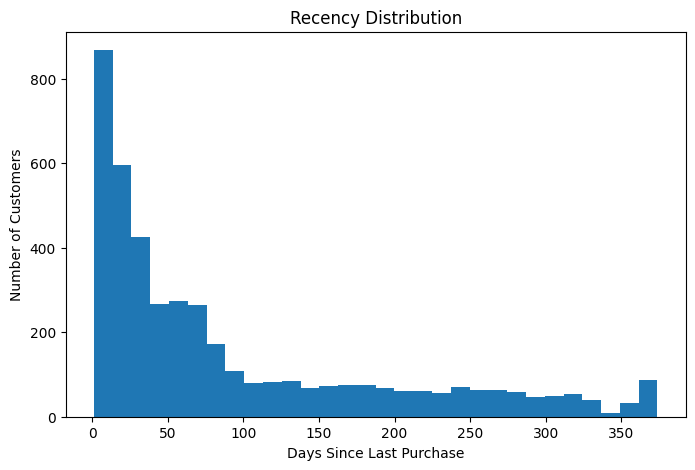

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Recency'], bins=30)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")
plt.show()

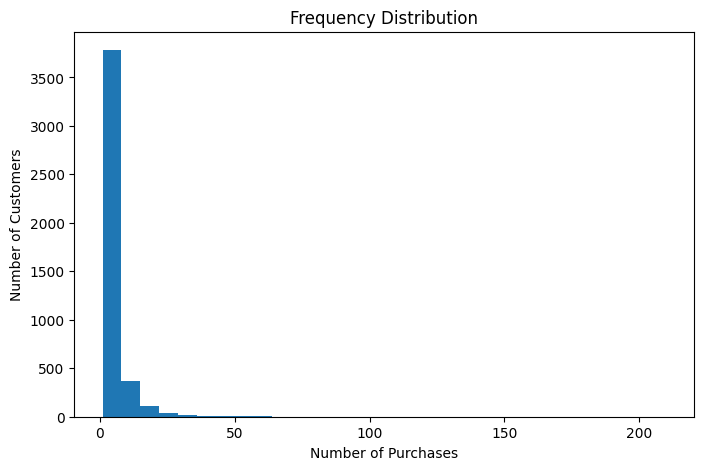

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Frequency'], bins=30)
plt.title("Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()

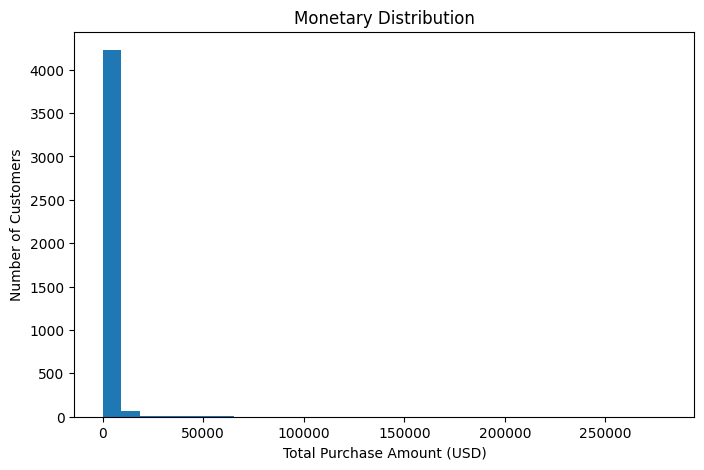

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(rfm['Monetary'], bins=30)
plt.title("Monetary Distribution")
plt.xlabel("Total Purchase Amount (USD)")
plt.ylabel("Number of Customers")
plt.show()

In [ ]:

rfm_log = rfm.copy()

rfm_log['Recency'] = np.log1p(rfm_log['Recency'])
rfm_log['Frequency'] = np.log1p(rfm_log['Frequency'])
rfm_log['Monetary'] = np.log1p(rfm_log['Monetary'])

print("--- RFM Data after Log Transformation (first 5 rows) ---")
display(rfm_log.head())

print("\n--- Descriptive Statistics of Log-Transformed RFM Data ---")
display(rfm_log.describe())

--- RFM Data after Log Transformation (first 5 rows) ---


,CustomerID,Recency,Frequency,Monetary
1,12346,5.789960,0.693147,11.253955
2,12347,1.098612,2.079442,8.368925
3,12348,4.330733,1.609438,7.494564
4,12349,2.995732,0.693147,7.472245
5,12350,5.739793,0.693147,5.815324



--- Descriptive Statistics of Log-Transformed RFM Data ---


,CustomerID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,3.830475,1.345478,6.587044
std,1721.889758,1.340215,0.683138,1.262262
min,12346.000000,0.693147,0.693147,0.000000
25%,13812.500000,2.944439,0.693147,5.728329
50%,15299.000000,3.951244,1.098612,6.506621
75%,16778.500000,4.962845,1.791759,7.415365
max,18287.000000,5.926926,5.351858,12.543284


**RFM LOG METHOD**

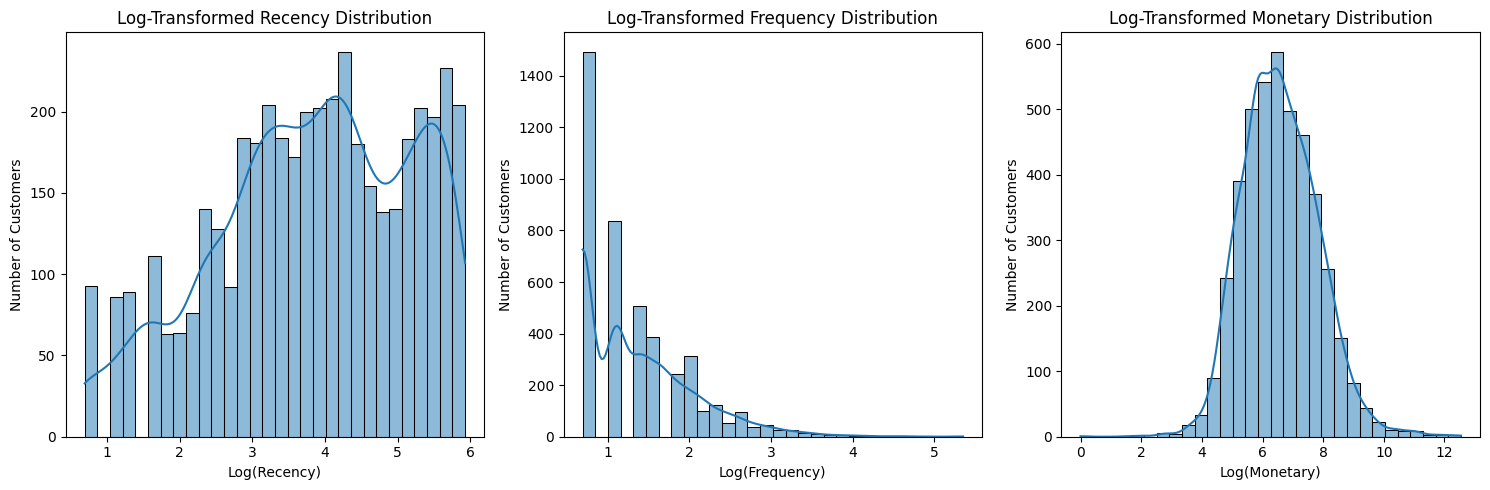

In [ ]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.histplot(rfm_log['Recency'], bins=30, kde=True)
plt.title('Log-Transformed Recency Distribution')
plt.xlabel('Log(Recency)')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 2)
sns.histplot(rfm_log['Frequency'], bins=30, kde=True)
plt.title('Log-Transformed Frequency Distribution')
plt.xlabel('Log(Frequency)')
plt.ylabel('Number of Customers')

plt.subplot(1, 3, 3)
sns.histplot(rfm_log['Monetary'], bins=30, kde=True)
plt.title('Log-Transformed Monetary Distribution')
plt.xlabel('Log(Monetary)')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

In [ ]:
print(rfm_log.columns)

Index(['CustomerID', 'Recency', 'Frequency', 'Monetary'], dtype='object')


In [ ]:
rfm_log = rfm_log[['Recency', 'Frequency', 'Monetary']]

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency', 'Frequency', 'Monetary'])

print("--- Scaled RFM Data (first 5 rows) ---")
display(rfm_scaled_df.head())

print("\n--- Descriptive Statistics of Scaled RFM Data ---")
display(rfm_scaled_df.describe())


--- Scaled RFM Data (first 5 rows) ---


,Recency,Frequency,Monetary
0,1.462236,-0.955013,3.697687
1,-2.038611,1.074523,1.411820
2,0.373310,0.386437,0.719046
3,-0.622914,-0.955013,0.701362
4,1.424800,-0.955013,-0.611449



--- Descriptive Statistics of Scaled RFM Data ---


,Recency,Frequency,Monetary
count,4.339000e+03,4.339000e+03,4.339000e+03
mean,4.912718e-18,2.833001e-16,-2.554613e-16
std,1.000115e+00,1.000115e+00,1.000115e+00
min,-2.341184e+00,-9.550131e-01,-5.219046e+00
25%,-6.611911e-01,-9.550131e-01,-6.803770e-01
50%,9.012174e-02,-3.614119e-01,-6.372078e-02
75%,8.450137e-01,6.533562e-01,6.562951e-01
max,1.564445e+00,5.865344e+00,4.719247e+00


**ELBOW METHOD TO IDENTIFY K (clusters)**

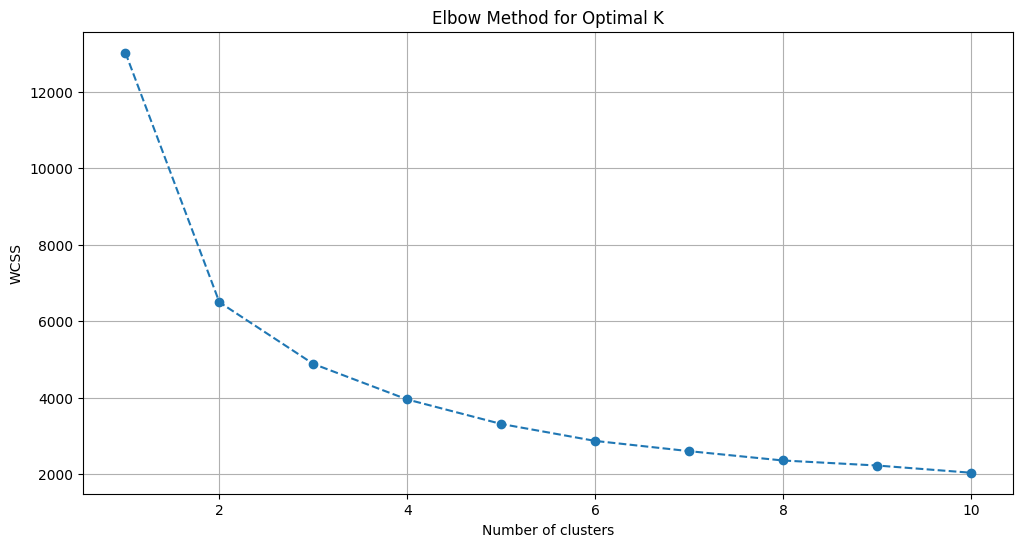

In [ ]:
from sklearn.cluster import KMeans

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(12, 6))
plt.plot(range(1,11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


In [ ]:
rfm['Monetary'].describe()

rfm.sort_values(by='Monetary', ascending=False).head(10)

rfm[rfm['Monetary'] > 50000].shape

rfm[rfm['Monetary'] <= 0].shape


(1, 4)

**KMEANS CLUSTERING**

In [ ]:
from sklearn.cluster import KMeans

n_clusters = 4 # elbow method decided k = 4
kmeans = KMeans(n_clusters=n_clusters, init='k-means++', random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled_df)

print("RFM DataFrame with K-Means Clusters (first 5 rows)")
display(rfm.head())

print(f"\nDistribution of customers across {n_clusters} clusters:")
display(rfm['Cluster'].value_counts())

RFM DataFrame with K-Means Clusters (first 5 rows)


,CustomerID,Recency,Frequency,Monetary,Cluster
1,12346,326,1,77183.60,1
2,12347,2,7,4310.00,2
3,12348,75,4,1797.24,1
4,12349,19,1,1757.55,0
5,12350,310,1,334.40,3



Distribution of customers across 4 clusters:


,count
Cluster,
3,1600
1,1186
0,836
2,717


**CLUSTER ANALYSIS**

--- Cluster Summary (Mean RFM Values) ---


,Recency,Frequency,Monetary
Cluster,,,
2,12.210600,13.711297,8059.183626
1,71.386172,4.050590,1779.936175
0,18.053828,2.150718,547.206615
3,183.078125,1.314375,337.690751


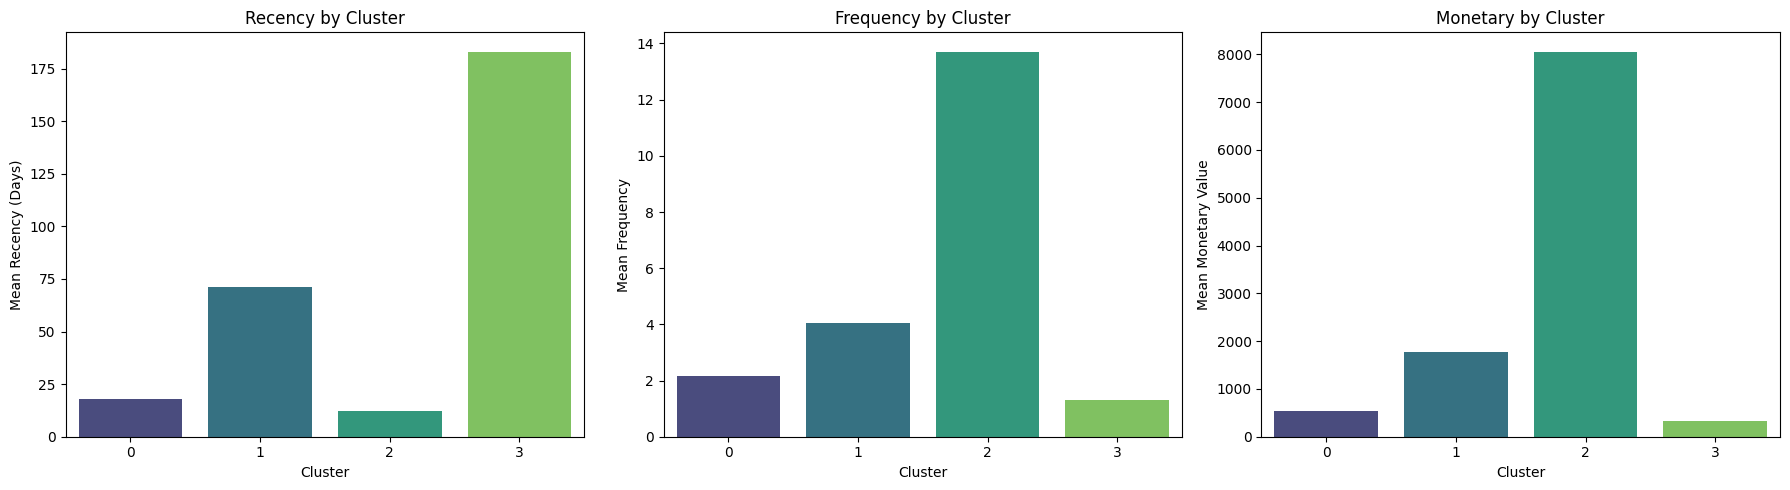

In [ ]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean().sort_values(by='Monetary', ascending=False)
print("--- Cluster Summary (Mean RFM Values) ---")
display(cluster_summary)

# Visualize the clusters
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.barplot(x=cluster_summary.index, y='Recency', data=cluster_summary, palette='viridis')
plt.title('Recency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Recency (Days)')

plt.subplot(1, 3, 2)
sns.barplot(x=cluster_summary.index, y='Frequency', data=cluster_summary, palette='viridis')
plt.title('Frequency by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Frequency')

plt.subplot(1, 3, 3)
sns.barplot(x=cluster_summary.index, y='Monetary', data=cluster_summary, palette='viridis')
plt.title('Monetary by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Mean Monetary Value')

plt.tight_layout()
plt.show()

**Cluster 2 – Champions**

Recency: 12 days

Frequency: 13.7 orders

Monetary: £8059

Most valuable customers who purchase frequently, spend the most, and have purchased recently

**Cluster 1 – Loyal Customers**

Recency: 71 days

Frequency: 4 orders

Monetary: £1779

Regular customers who contribute consistently to business revenue.

Cluster 0 – Potential Loyalists

Recency: 18 days

Frequency: 2 orders

Monetary: £547

Recently acquired customers with potential to become loyal customers in the future.

Cluster 3 – Lost Customers

Recency: 183 days

Frequency: 1 order

Monetary: £338

Inactive customers who have not purchased recently and require re-engagement strategies

In [ ]:
cluster_labels = {
    2: 'Champions',
    1: 'Loyal Customers',
    0: 'Potential Loyalists',
    3: 'Lost Customers'
}

rfm['Segment'] = rfm['Cluster'].map(cluster_labels)

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    rfm_scaled_df,
    rfm['Cluster']
)

print(score)

0.3369232412201418


In [ ]:
rfm['Monetary'].describe()

,Monetary
count,4339.000000
mean,2048.215924
std,8984.248352
min,0.000000
25%,306.455000
50%,668.560000
75%,1660.315000
max,280206.020000


In [ ]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    5,
    labels=[5,4,3,2,1]
)

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

In [ ]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster,R_Score,F_Score,M_Score
1,12346,326,1,77183.60,1,1,1,5
2,12347,2,7,4310.00,2,5,5,5
3,12348,75,4,1797.24,1,2,4,4
4,12349,19,1,1757.55,0,4,1,4
5,12350,310,1,334.40,3,1,1,2


In [ ]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [ ]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal Customers'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

In [ ]:
rfm['Segment'].value_counts()

,count
Segment,
Others,2557
Loyal Customers,792
At Risk,643
Champions,347


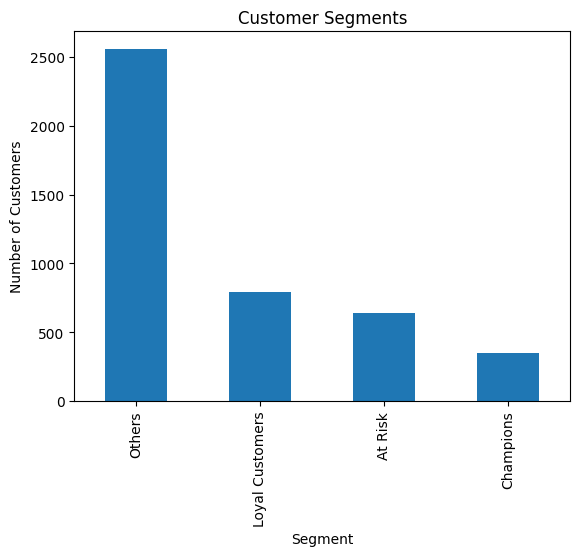

In [ ]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(
    kind='bar'
)

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
rfm.head()
rfm['Segment'].value_counts()

,count
Segment,
Lost Customers,1600
Loyal Customers,1186
Potential Loyalists,836
Champions,717


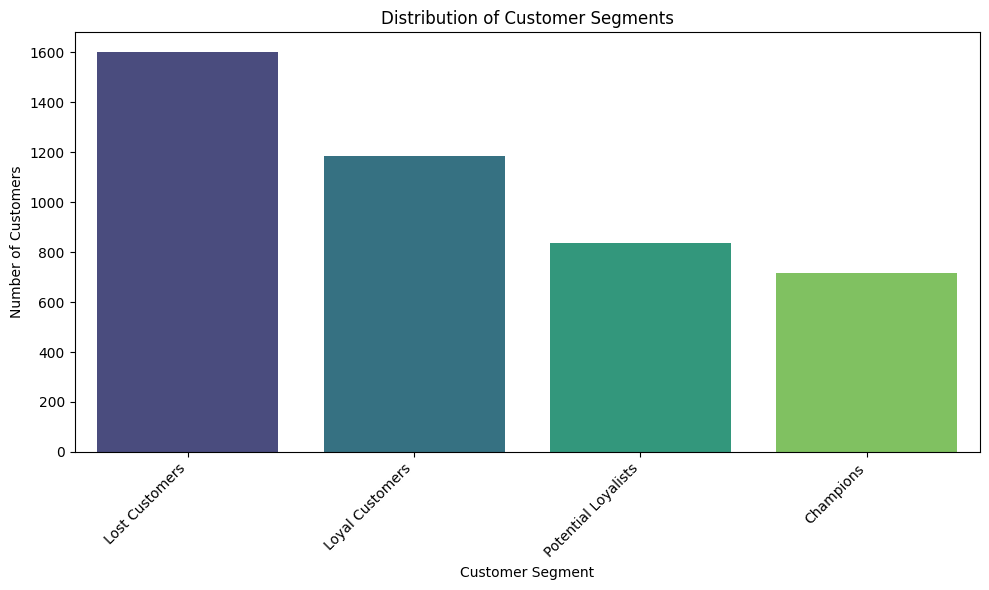

In [ ]:
segment_counts = rfm['Segment'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=segment_counts.index, y=segment_counts.values, palette='viridis')
plt.title('Distribution of Customer Segments')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
rfm_segment_summary = rfm.groupby('Segment')[['Recency', 'Frequency', 'Monetary']].mean().sort_values(by='Monetary', ascending=False)
display(rfm_segment_summary)

,Recency,Frequency,Monetary
Segment,,,
Champions,12.210600,13.711297,8059.183626
Loyal Customers,71.386172,4.050590,1779.936175
Potential Loyalists,18.053828,2.150718,547.206615
Lost Customers,183.078125,1.314375,337.690751


**LOGISTICS REGRESSION**

**Above 90 are  churns which is 1**
THE rest are not churn which is 0

In [ ]:
rfm['churn'] = (rfm['Recency'] > 90).astype(int)

In [ ]:
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary,Cluster,R_Score,F_Score,M_Score,RFM_Score,Segment,churn
1,12346,326,1,77183.60,1,1,1,5,115,Loyal Customers,1
2,12347,2,7,4310.00,2,5,5,5,555,Champions,0
3,12348,75,4,1797.24,1,2,4,4,244,Loyal Customers,0
4,12349,19,1,1757.55,0,4,1,4,414,Potential Loyalists,0
5,12350,310,1,334.40,3,1,1,2,112,Lost Customers,1


In [ ]:
rfm['churn'].value_counts(normalize=True)*100

,proportion
churn,
0,66.605209
1,33.394791


In [ ]:
X = rfm[['Frequency','Monetary']]
y = rfm['churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.716589861751152
Precision: 0.5910652920962199
Recall: 0.5752508361204013
F1 Score: 0.5830508474576271


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

log_accuracy = accuracy_score(y_test, y_pred)
log_precision = precision_score(y_test, y_pred)
log_recall = recall_score(y_test, y_pred)
log_f1 = f1_score(y_test, y_pred)

**RANDOM FOREST**

In [ ]:
X = rfm[['Frequency','Monetary']]
y = rfm['churn']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = model.predict(X_test)

NameError: name 'model' is not defined

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.716589861751152
Precision: 0.5910652920962199
Recall: 0.5752508361204013
F1 Score: 0.5830508474576271


In [ ]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

     Feature  Importance
1   Monetary    0.880008
0  Frequency    0.119992


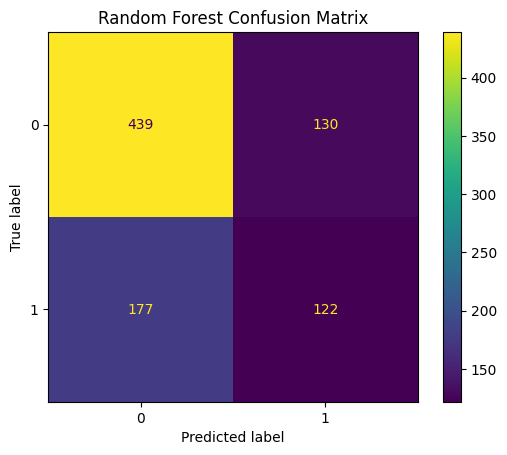

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test
)

plt.title("Random Forest Confusion Matrix")
plt.show()

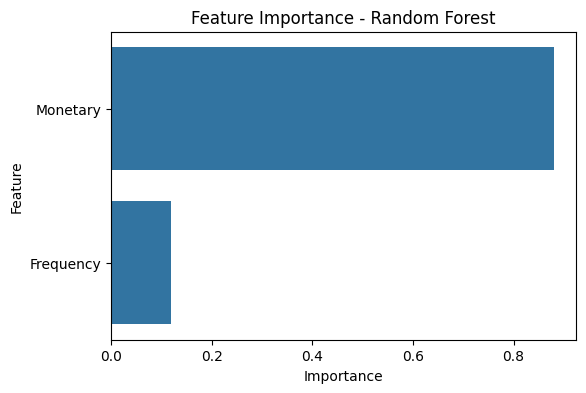

In [ ]:
import seaborn as sns

plt.figure(figsize=(6,4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=importance
)

plt.title("Feature Importance - Random Forest")
plt.show()

**Random Forest Metrics**

In [ ]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [log_accuracy, rf_accuracy],
    'Precision': [log_precision, rf_precision],
    'Recall': [log_recall, rf_recall],
    'F1 Score': [log_f1, rf_f1]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.716590,0.591065,0.575251,0.583051
1,Random Forest,0.646313,0.484127,0.408027,0.442831


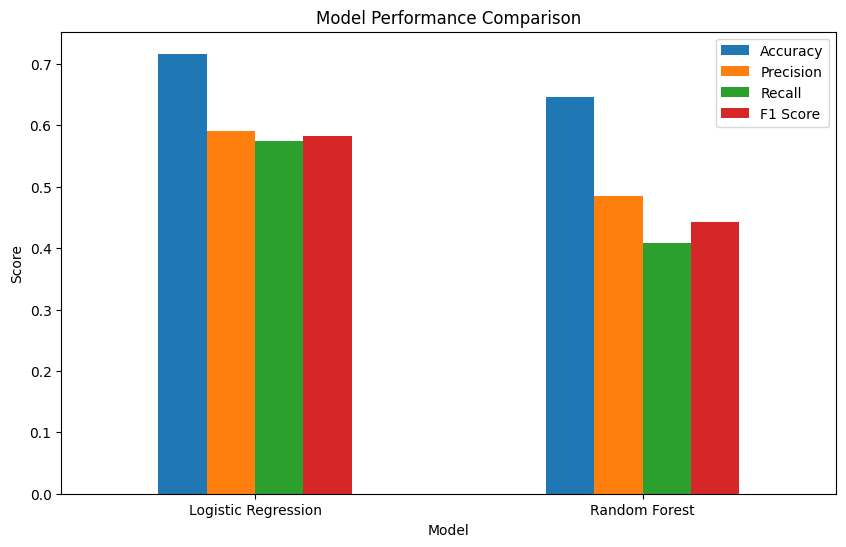

In [ ]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='best')
plt.show()

**Exporting Data for Power BI**

In [ ]:
# Export the cleaned transactional dataset
dataset.to_csv('cleaned_transactions.csv', index=False)
print('Exported cleaned_transactions.csv')

# Export the RFM dataframe with segments
rfm.to_csv('rfm_with_segments.csv', index=False)
print('Exported rfm_with_segments.csv')

# Export the cluster summary
cluster_summary.to_csv('rfm_cluster_summary.csv', index=True)
print('Exported rfm_cluster_summary.csv')

# Export product revenue
product_revenue.to_csv('product_revenue.csv', index=False)
print('Exported product_revenue.csv')

# Export customer revenue
customer_revenue.to_csv('customer_revenue.csv', index=False)
print('Exported customer_revenue.csv')

# Export top countries by sales
top_countries.to_csv('top_countries_sales.csv', index=False)
print('Exported top_countries_sales.csv')

# Export daily sales data
daily_sales.to_csv('daily_sales.csv', index=False)
print('Exported daily_sales.csv')

# Export monthly sales data
monthly_sales.to_csv('monthly_sales.csv', index=False)
print('Exported monthly_sales.csv')

# Export feature importance from Random Forest
importance.to_csv('rf_feature_importance.csv', index=False)
print('Exported rf_feature_importance.csv')

# Export model comparison metrics
comparison.to_csv('model_performance_comparison.csv', index=False)
print('Exported model_performance_comparison.csv')

Exported cleaned_transactions.csv
Exported rfm_with_segments.csv
Exported rfm_cluster_summary.csv
Exported product_revenue.csv
Exported customer_revenue.csv
Exported top_countries_sales.csv
Exported daily_sales.csv
Exported monthly_sales.csv
Exported rf_feature_importance.csv
Exported model_performance_comparison.csv
